In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [16]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1QfdgmPwMU-OdySntlOF6x2cjH1M5ZJWi')
print("Data awal:")
display(df.head())

Data awal:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [17]:
le = LabelEncoder()
cat_columns = ['Cloud Cover', 'Season', 'Location', 'Weather Type']

for col in cat_columns:
    df[col] = le.fit_transform(df[col])

print("\nData setelah di-encode (menjadi angka):")
display(df.head())


Data setelah di-encode (menjadi angka):


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


In [19]:
X = df.drop('Weather Type', axis=1)
y = df['Weather Type']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE (Handling Imbalance)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nShape Train awal: {X_train.shape}")
print(f"Shape Train setelah SMOTE: {X_train_res.shape}")


Shape Train awal: (10560, 10)
Shape Train setelah SMOTE: (10636, 10)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

param_grid = {'n_neighbors': np.arange(1, 30)}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5)

print("\nSedang training model (GridSearch)...")
knn_cv.fit(X_train_scaled, y_train_res)

print(f"K Terbaik: {knn_cv.best_params_['n_neighbors']}")
print(f"Score Terbaik: {knn_cv.best_score_:.4f}")


Sedang training model (GridSearch)...
K Terbaik: 5
Score Terbaik: 0.8979


In [26]:
best_knn = knn_cv.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       651
           1       0.86      0.88      0.87       647
           2       0.93      0.93      0.93       701
           3       0.93      0.87      0.90       641

    accuracy                           0.89      2640
   macro avg       0.89      0.89      0.89      2640
weighted avg       0.89      0.89      0.89      2640



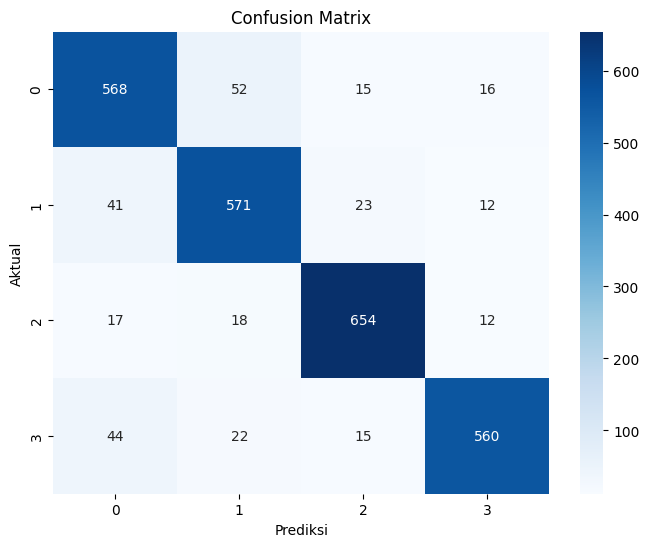

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

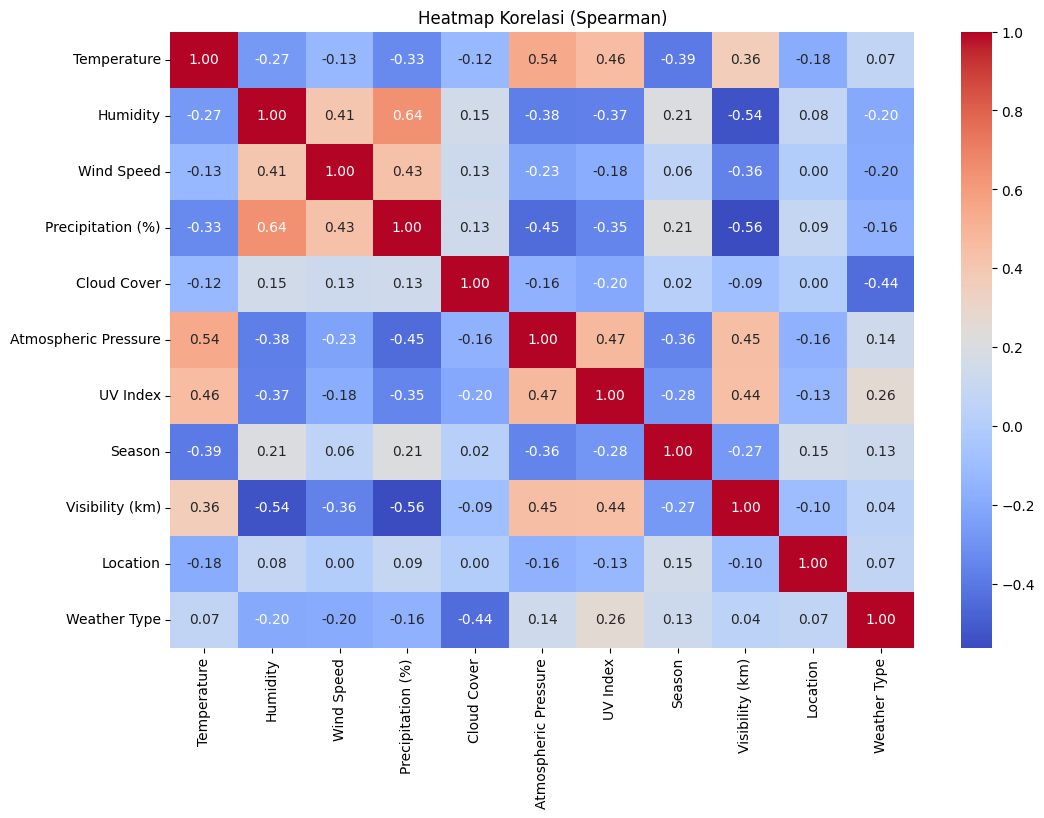

In [24]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(method='spearman') # Menggunakan metode spearman seperti praktikum
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Heatmap Korelasi (Spearman)')
plt.show()

/tmp/ipython-input-1475156073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weather Type', data=df, palette='Set2')


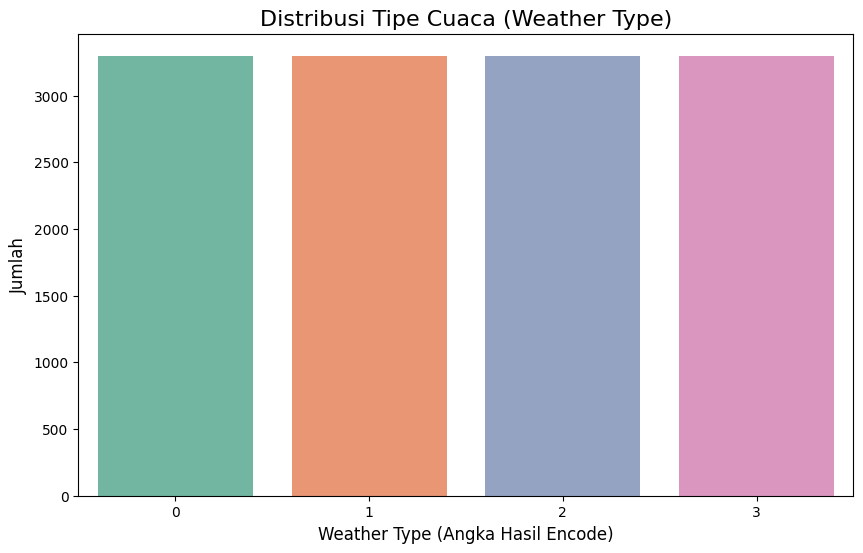

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Weather Type', data=df, palette='Set2')

plt.title('Distribusi Tipe Cuaca (Weather Type)', fontsize=16)
plt.xlabel('Weather Type (Angka Hasil Encode)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.show()

In [ ]:
# ==========================================
# 1. IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ==========================================
# 2. LOAD DATA & ENCODING
# ==========================================
df = pd.read_csv('weather_classification_data.csv')

# Encoding (Ubah Teks ke Angka) agar bisa diproses Model & Heatmap
le = LabelEncoder()
cat_columns = ['Cloud Cover', 'Season', 'Location', 'Weather Type']

# Kita simpan mapping agar tahu (Misal: 0=Cloudy, 1=Rainy, dst)
print("Mapping Label (Untuk referensi grafik nanti):")
for col in cat_columns:
    df[col] = le.fit_transform(df[col])
    # Tampilkan contoh mapping untuk kolom Target
    if col == 'Weather Type':
        print(f"  {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

# ==========================================
# 3. SPLIT DATA & SMOTE
# ==========================================
X = df.drop('Weather Type', axis=1)
y = df['Weather Type']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE (Handling Imbalance)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ==========================================
# 4. SCALING & MODELING (KNN)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# GridSearch untuk mencari K terbaik
param_grid = {'n_neighbors': np.arange(1, 30)}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5)

print("\n--- Sedang Melatih Model (Tunggu Sebentar) ---")
knn_cv.fit(X_train_scaled, y_train_res)
print(f"K Terbaik: {knn_cv.best_params_['n_neighbors']}")

# ==========================================
# 5. EVALUASI MODEL
# ==========================================
best_knn = knn_cv.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Evaluasi Model)')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# ==========================================
# 6. VISUALISASI DATA (Di Akhir)
# ==========================================
print("\n--- VISUALISASI DATA ---")

# A. HEATMAP KORELASI
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Heatmap Korelasi (Spearman)')
plt.show()

# B. COUNTPLOT DISTRIBUSI
plt.figure(figsize=(10, 6))
sns.countplot(x='Weather Type', data=df, palette='Set2')
plt.title('Distribusi Tipe Cuaca (Weather Type)', fontsize=16)
plt.xlabel('Weather Type (Angka Hasil Encode)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.show()